In [1]:
import Pkg
Pkg.activate("./")
Pkg.instantiate()

  Activating project at `~/Desktop/git_projects/Causal sets/CausalSetZoology/analysis`


In [2]:
using Revise
using Statistics
using CairoMakie
using LinearAlgebra
includet("analysis.jl")

In [3]:
using ProgressMeter
using Distributed

@everywhere using JLD2, Arpack, SparseArrays, LinearAlgebra, Statistics
@everywhere BLAS.set_num_threads(1)

In [4]:
@everywhere using CausalSetZoology

In [4]:
function fig_path(fig_name::String)
        path = "/Users/fabianwagner/Dropbox/Fabian/Research/Shared Folders/CausalSetZoology/figs/"
        #"/Users/fabian/Dropbox/Fabian/Research/Shared Folders/CausalSetZoology/figs/"
        return "$(path)$(fig_name)"
end

fig_path (generic function with 1 method)

In [6]:
@everywhere function sparse_symmetric_link_adjacency(cset::SparseLinksCauset)
    n = cset.atom_count

    I = Int[]
    J = Int[]
    V = Float64[]

    # Each causal link i -> j becomes two undirected edges: i--j and j--i
    for i in 1:n
        for j32 in cset.future_links[i]
            j = Int(j32)

            push!(I, i)
            push!(J, j)
            push!(V, 1.0)

            push!(I, j)
            push!(J, i)
            push!(V, 1.0)
        end
    end

    return sparse(I, J, V, n, n)
end

@everywhere function sparse_symmetric_normalized_laplacian(cset::SparseLinksCauset)
    A = sparse_symmetric_link_adjacency(cset)
    n = cset.atom_count

    d = vec(sum(A; dims = 2))

    dinvsqrt = zeros(Float64, n)
    nonzero_degree = d .> 0
    dinvsqrt[nonzero_degree] .= 1.0 ./ sqrt.(d[nonzero_degree])

    Dmh = spdiagm(0 => dinvsqrt)

    L = spdiagm(0 => ones(Float64, n)) - Dmh * A * Dmh

    return Symmetric(L)
end

@everywhere function laplacian_extreme_eigenvalues(links; nev_small = 2, tol = 1e-6)
    L = sparse_symmetric_normalized_laplacian(links)

    λsmall = eigs(L; nev = nev_small, which = :SM, tol = tol, ritzvec = false)[1]
    λlarge = eigs(L; nev = 1, which = :LM, tol = tol, ritzvec = false)[1]

    λs = sort!(real.(λsmall))

    λ2 = if nev_small == 2
        λs[2]
    else
        first(λ for λ in λs if λ > 1e-10)
    end

    λmax = real(λlarge[1])

    return (λ2, λmax)
end

@everywhere function process_batch_distributed(path, batch; nev_small = 2, tol = 1e-6)
    JLD2.jldopen(path, "r") do f
        links_batch = f["batches"]["$(batch)"]["links"]

        result = Vector{Tuple{Float64, Float64}}(undef, length(links_batch))

        @inbounds for i in eachindex(links_batch)
            result[i] = laplacian_extreme_eigenvalues(
                links_batch[i];
                nev_small = nev_small,
                tol = tol,
            )
        end

        return result
    end
end

# Second and last eigenvalues vs Size for Manifoldlike Simply Connected Datasets

This notebook loads all available `manifoldlike_simply_connected_<size>_10000` statistics files,
computes the second and last Laplacian eigenvalue for each sample, and plots the mean eigenvalues with asymmetric error bars as a function of size.

In [7]:
analysis_root_man = "/Volumes/Causal Set Silo/causal_sets/analysis/link_degree_only"

function manifoldlike_size_path_pairs(root::AbstractString)
    pairs = Tuple{Int,String}[]
    for name in readdir(root)
        m = match(r"^manifoldlike_simply_connected_link_degree_(\d+)_1000$", name)
        msm = match(r"^manifoldlike_simply_connected_link_degree_(\d+)_100$", name)
        isnothing(m) && isnothing(msm) && continue

        size = isnothing(m) ? parse(Int, msm.captures[1]) : parse(Int, m.captures[1])
        ispow2(size) || continue
        size < 1024 && continue

        path = joinpath(root, name, "dataset.jld2")
        isfile(path) || continue
        push!(pairs, (size, path))
    end
    sort!(pairs; by = first)
    return pairs
end


size_path_pairs_man = manifoldlike_size_path_pairs(analysis_root_man)
sizes_man = first.(size_path_pairs_man)
paths_man = last.(size_path_pairs_man)

sizes_man

7-element Vector{Int64}:
  1024
  2048
  4096
  8192
 16384
 32768
 65536

In [8]:
paths_man = [p[2] for p in size_path_pairs_man]

eigvals_man = Vector{Vector{Tuple{Float64, Float64}}}(undef, length(paths_man))

p = Progress(length(paths_man); desc = "Paths")

for (ipath, path) in enumerate(paths_man)
    nbatches = JLD2.jldopen(path, "r") do f
        f["meta"]["nbatches"]
    end

    batch_results = pmap(
        batch -> process_batch_distributed(
            path,
            batch;
            nev_small = 2,
            tol = 1e-6,
        ),
        1:nbatches,
    )

    eigvals_man[ipath] = vcat(batch_results...)
    next!(p)
end

Paths 100%|██████████████████████████████████████████████| Time: 1:44:29


In [5]:
struct NormalizedLinkLaplacianOp <: AbstractMatrix{Float64}
    cset::SparseLinksCauset
    dinvsqrt::Vector{Float64}
end

Base.size(L::NormalizedLinkLaplacianOp) =
    (L.cset.atom_count, L.cset.atom_count)

Base.eltype(::Type{NormalizedLinkLaplacianOp}) = Float64
Base.eltype(::NormalizedLinkLaplacianOp) = Float64

LinearAlgebra.issymmetric(::NormalizedLinkLaplacianOp) = true
LinearAlgebra.ishermitian(::NormalizedLinkLaplacianOp) = true
Base.size(L::NormalizedLinkLaplacianOp, d::Int) = d <= 2 ? L.cset.atom_count : 1

In [6]:
function normalized_link_laplacian_operator(cset::SparseLinksCauset)
    n = cset.atom_count

    deg = Vector{Float64}(undef, n)

    @inbounds for i in 1:n
        deg[i] = length(cset.future_links[i]) + length(cset.past_links[i])
    end

    dinvsqrt = zeros(Float64, n)
    @inbounds for i in 1:n
        if deg[i] > 0
            dinvsqrt[i] = inv(sqrt(deg[i]))
        end
    end

    return NormalizedLinkLaplacianOp(cset, dinvsqrt)
end

normalized_link_laplacian_operator (generic function with 1 method)

In [7]:
using LinearAlgebra
using Base.Threads

function LinearAlgebra.mul!(
    y::AbstractVector{Float64},
    L::NormalizedLinkLaplacianOp,
    x::AbstractVector{Float64},
)
    cset = L.cset
    dinv = L.dinvsqrt
    n = cset.atom_count

    @threads :dynamic for i in 1:n
        wi = dinv[i]

        if wi == 0.0
            y[i] = x[i]
            continue
        end

        acc = 0.0

        @inbounds for j in cset.future_links[i]
            acc += dinv[j] * x[j]
        end

        @inbounds for j in cset.past_links[i]
            acc += dinv[j] * x[j]
        end

        y[i] = x[i] - wi * acc
    end

    return y
end

In [8]:
function laplacian_extreme_eigenvalues_matrixfree(links; nev_small = 2, tol = 1e-6)
    Lop = normalized_link_laplacian_operator(links)

    λsmall = eigs(
        Lop;
        nev = nev_small,
        which = :SM,
        tol = tol,
        ritzvec = false,
    )[1]

    λlarge = eigs(
        Lop;
        nev = 1,
        which = :LM,
        tol = tol,
        ritzvec = false,
    )[1]

    λs = sort!(real.(λsmall))

    λ2 = if nev_small == 2
        λs[2]
    else
        first(λ for λ in λs if λ > 1e-10)
    end

    λmax = real(λlarge[1])

    return (λ2, λmax)
end

laplacian_extreme_eigenvalues_matrixfree (generic function with 1 method)

In [9]:
function process_batch_matrixfree_into!(out, f, batch; nev_small = 2, tol = 1e-6)
    links_batch = f["batches"]["$(batch)"]["links"]  # loads one full batch

    sizehint!(out, length(out) + length(links_batch))

    for links in links_batch
        push!(
            out,
            laplacian_extreme_eigenvalues_matrixfree(
                links;
                nev_small = nev_small,
                tol = tol,
            ),
        )
    end

    return out
end

process_batch_matrixfree_into! (generic function with 1 method)

In [44]:
paths_man = [p[2] for p in size_path_pairs_man]

eigvals_man = Vector{Vector{Tuple{Float64, Float64}}}(undef, length(paths_man))

p = Progress(length(paths_man); desc = "Paths")

for (ipath, path) in enumerate(paths_man)
    path_results = Tuple{Float64, Float64}[]

    JLD2.jldopen(path, "r") do f
        nbatches = f["meta"]["nbatches"]

        for batch in 1:nbatches
            process_batch_matrixfree_into!(
                path_results,
                f,
                batch;
                nev_small = 2,
                tol = 1e-6,
            )

            GC.gc()
        end
    end

    eigvals_man[ipath] = path_results
    next!(p)
end

Paths 100%|██████████████████████████████████████████████| Time: 0:35:23


In [ ]:
Lop = normalized_link_laplacian_operator(links)

λsmall = eigs(Lop; nev=2, which=:SM, tol=1e-6, ritzvec=false)[1]

λlarge = eigs(Lop; nev=1, which=:LM, tol=1e-6, ritzvec=false)[1]

λ2 = sort(real.(λsmall))[2]

λmax = real(λlarge[1])

In [45]:
λ₂s = [[vals[1] for vals in val_sets] for val_sets in eigvals_man]
λ₂means = [Statistics.mean(val) for val in λ₂s]
λ₂stds = [Statistics.std(val) for val in λ₂s]

7-element Vector{Float64}:
 0.02537643852462039
 0.022935081134843015
 0.020347121535062615
 0.019138628813540268
 0.017849132510781813
 0.01658748839625746
 0.015503670381238817

In [46]:
λₙs = [[vals[2] for vals in val_sets] for val_sets in eigvals_man]
λₙmeans = [Statistics.mean(val) for val in λₙs]
λₙstds = [Statistics.std(val) for val in λₙs]

7-element Vector{Float64}:
 0.02491899393329725
 0.02411684729930884
 0.023061861273883714
 0.020944276045209553
 0.021128291656714624
 0.019953779593037915
 0.01872534898377169

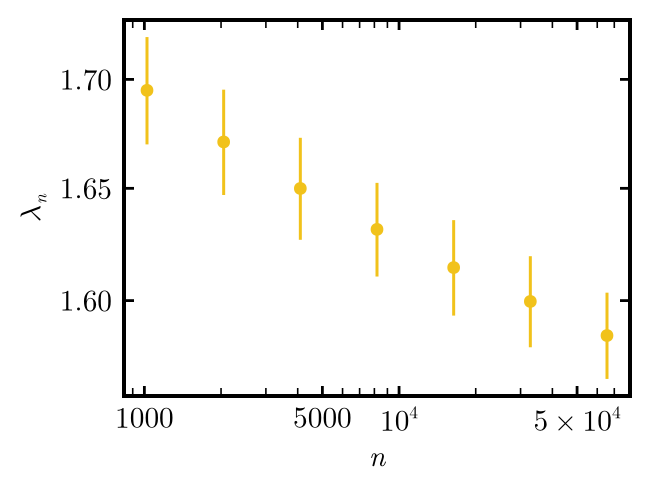

In [47]:
figsize = apply_paper_theme!(; logscale_x=true, logscale_y=true)
fig = Figure(; size = figsize)
ax = Axis(
    fig[1,1];
    xscale = log10,
    yscale = log10,
    yticks = [1.5, 1.55, 1.6, 1.65, 1.7, 1.75],
    xlabel = L"n",
    ylabel = L"\lambda_n")
scatter!(ax, sizes_man, λₙmeans)
errorbars!(ax, sizes_man, λₙmeans, λₙstds)

save(fig_path("graph_observables/last_ev_size.pdf"), fig)

fig

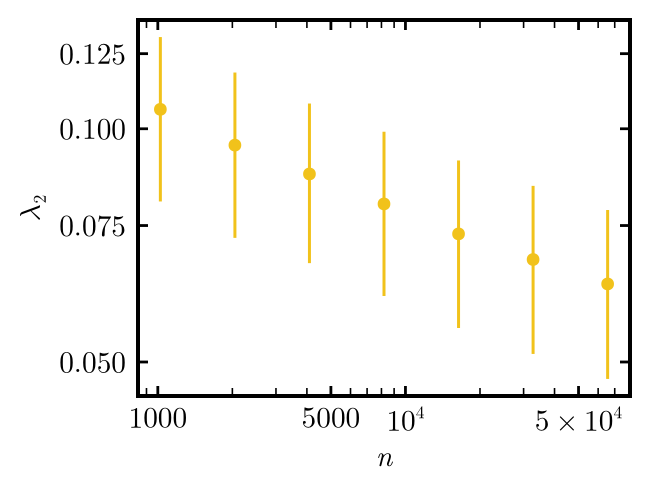

In [48]:
figsize = apply_paper_theme!(; logscale_x=true, logscale_y=true)
fig = Figure(; size = figsize)
ax = Axis(
    fig[1,1];
    xscale = log10,
    yscale = log10,
    yticks = [0.05, 0.075, 0.1, 0.125, 0.15],
    xlabel = L"n",
    ylabel = L"\lambda_2")
scatter!(ax, sizes_man, λ₂means)
errorbars!(ax, sizes_man, λ₂means, λ₂stds)

save(fig_path("graph_observables/second_ev_size.pdf"), fig)

fig

# Second and last eigenvalues vs Size for Minkowski Datasets

In [11]:
analysis_root = "/Volumes/Causal Set Silo/causal_sets/analysis/link_degree_only/"

function minkowski_size_path_pairs(root::AbstractString)
    pairs = Tuple{Int,String}[]
    for name in readdir(root)
        m = match(r"^minkowski_sprinkling_link_degree_(\d+)_1000$", name)
        msm = match(r"^minkowski_sprinkling_link_degree_(\d+)_100$", name)
        isnothing(m) && isnothing(msm) && continue
        size = isnothing(m) ? parse(Int, msm.captures[1]) : parse(Int, m.captures[1])
        path = joinpath(root, name, "dataset.jld2")
        isfile(path) || continue
        push!(pairs, (size, path))
    end
    sort!(pairs; by = first)
    return pairs
end

size_path_pairs_mink = minkowski_size_path_pairs(analysis_root)
sizes_mink = first.(size_path_pairs_mink)
paths_mink = last.(size_path_pairs_mink)

sizes_mink

12-element Vector{Int64}:
    1024
    2048
    4096
    8192
   16384
   32768
   65536
  131072
  262144
  262144
  524288
 1048576

In [12]:
function split_eigval_tuples(eigvals::Vector{Tuple{Float64, Float64}})
    second_ev = Float64[x[1] for x in eigvals]
    last_ev   = Float64[x[2] for x in eigvals]
    return second_ev, last_ev
end

function save_path_result!(outpath::AbstractString, size, eigvals::Vector{Tuple{Float64, Float64}})
    second_ev, last_ev = split_eigval_tuples(eigvals)

    size_key = string(size)

    JLD2.jldopen(outpath, "a+") do f
        f["$size_key/second_ev"] = second_ev
        f["$size_key/last_ev"]   = last_ev
    end

    return nothing
end

save_path_result! (generic function with 1 method)

In [17]:
paths_mink = [p[2] for p in size_path_pairs_mink[10:10]]
sizes_mink = [p[1] for p in size_path_pairs_mink[10:10]]

nbatches_mink = [
    JLD2.jldopen(path, "r") do f
        f["meta"]["nbatches"]
    end
    for path in paths_mink
]

total_batches = sum(nbatches_mink)

p = Progress(total_batches; desc = "Eigenvalues")

eigvals_mink = Vector{Vector{Tuple{Float64, Float64}}}(undef, length(paths_mink))

for (ipath, (size, path, nbatches)) in enumerate(zip(sizes_mink, paths_mink, nbatches_mink))
    path_results = Tuple{Float64, Float64}[]

    JLD2.jldopen(path, "r") do f
        for batch in 1:nbatches
            ProgressMeter.update!(
                p,
                desc = "size=$size, path=$ipath/$(length(paths_mink)), batch=$batch/$nbatches"
            )

            process_batch_matrixfree_into!(
                path_results,
                f,
                batch;
                nev_small = 2,
                tol = 1e-6,
            )

            next!(p)
            GC.gc()
        end
    end

    eigvals_mink[ipath] = path_results
    save_path_result!(outpath, size, path_results)
end

size=262144, path=1/1, batch=17/24  67%|███████████▍     |  ETA: 3:32:20

: 

In [ ]:
paths_mink = [p[2] for p in size_path_pairs_mink]

eigvals_mink = Vector{Vector{Tuple{Float64, Float64}}}(undef, length(paths_mink))

p = Progress(length(paths_mink); desc = "Paths")

for (ipath, path) in enumerate(paths_mink)
    path_results = Tuple{Float64, Float64}[]

    JLD2.jldopen(path, "r") do f
        nbatches = f["meta"]["nbatches"]

        for batch in 1:nbatches
            process_batch_matrixfree_into!(
                path_results,
                f,
                batch;
                nev_small = 2,
                tol = 1e-6,
            )

            GC.gc()
        end
    end

    eigvals_mink[ipath] = path_results
    next!(p)
end

Paths  75%|██████████████████████████████████▌           |  ETA: 1:24:10

: 

: 